# **Entreno de ángulos mediante el algoritmo de Ben Priestley**

En la siguiente sección voy a realizar un preentreno de ángulos para instancias pequeñas de CVP basados en la factorización de N

In [40]:
%load_ext autoreload
%autoreload 2

import time
import sympy
import numpy as np
from math import log, log2

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from Crypto.Util import number


from tqdm.notebook import tqdm

import random

from scipy.optimize import curve_fit

#Importar de función interna
from modules import schnorr_lattice as sl
from modules import qaoa
from modules import utils

from modules.functions import solve_cvp, solve_cvp_with_opt_paramters

from sklearn.cluster import KMeans



from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
seed = 42
random.seed(seed)

In [3]:
def generate_N(bitLength):
    """
    param bitLength: cantidad de bits de N

    return: N = p*q de bitLength bits
    """
    
    min_p_bit_length = max(2, bitLength // 4)
    max_p_bit_length = bitLength - min_p_bit_length

    

    while True:
        p_bit_length = random.randint(min_p_bit_length, max_p_bit_length)

        p = number.getPrime(p_bit_length)

        q_bit_length = bitLength - p_bit_length + 1

        q = number.getPrime(q_bit_length)

        N = p * q

        if N.bit_length() == bitLength:
            return N


## **Generación de set de entrenamiento**

Código de generación del set de entrenamiento

In [4]:
def generate_train_set(min, max, set_length):
    train_set = []
    bitLengths = []
    
    for _ in range(set_length):
        bitlength = random.randint(min, max)
        N = generate_N(bitlength)
        train_set.append(N)
        bitLengths.append(bitlength)

    
    train_df = pd.DataFrame({
        'N': train_set,
        'Bit_length': bitLengths
    })

    return train_df


## **Generación de set de validación**

Código de generación del set de validación

In [5]:
def generate_val_set(min, max, n_per_length):
    validation_set = []


    for length in range(min, max):
        for _ in range(n_per_length):
            N = generate_N(length)
            validation_set.append(N)

    val_df = pd.DataFrame({
        'N': validation_set,
        'bitLength': [n.bit_length() for n in validation_set]
    })

    return val_df



## **Proceso de entrenamiento**

In [4]:
#Función para ver el escalado de la probabilidad de obtener una mejor solución del paper de Ben Priestley
def scaling_function(x, alpha):
    return 1/(2**(alpha*x))

In [5]:
#Funciones para Clusterizar lo angulos

def normalize_angles(angles: list[list[float]]):
    #Normalizo los angulos en el intervalo: [-π, π]
    nangles = np.array(angles)
    nangles = (nangles + np.pi) % (2*np.pi) - np.pi
    return nangles


def obtain_kmeans(k: int, angles: np.ndarray) -> list[list[float]]:
    kmeans = KMeans(n_clusters = k, random_state = seed, n_init="auto")

    n_angles = angles.shape[1]
    features = np.hstack([
        np.column_stack([np.cos(angles[:, i]), np.sin(angles[:, i])])
        for i in range(n_angles)
    ])

    kmeans.fit(features)
    c = kmeans.cluster_centers_
    centroides = np.column_stack([
        np.arctan2(c[:, 2*i + 1], c[:, 2*i])
        for i in range(n_angles)
    ])

    return centroides.tolist()

In [ ]:
def qaoa_pretrain_algorithm(train_set: np.ndarray, val_set: np.ndarray, epochs: int = 5, 
                            clusterize: bool = True, clusters: int = 10,
                            delta: float = 0.75, l: int = 1, c: int = 3, min_method: str = 'Nelder-Mead', p: int = 1,
                            normalizeHc: bool = False, q: int = 10,
                            seed: int = 42, verbose: bool = False, progress_bar: bool = False):
    """
    TODO
    """
    # Inicializacion
    np.random.seed(seed)
    a_op = None #Asignación de angulos inicial
    best_alpha = np.inf
    val_stats = {}

    #train_len = train_set.size
    #val_len = val_set.size

    
    for epoch_idx in tqdm(range(1, epochs + 1), desc = "Epochs") if progress_bar else range(1, epochs + 1): #Episodios de entreno

        tic = time.perf_counter()


        angles_population = [] #Conjunto con los angulos calculados para cada instancia de entreno
        angles_clusters_rep = [] #Conjunto con los representantes de los clusters 

        #Entrenamiento
        for tN in tqdm(train_set, desc = "Training") if progress_bar else train_set: 
            
            cvp = sl.schnorrCVP(tN, c, l, seed, set_seed = False, verbose = False)#Genero una instancia para realizar los calculos
            instance = cvp.generate_cvp(q, verbose = False)

            if a_op is not None: x0 = np.asarray(a_op)
            else: x0 = np.asarray([0.0]*(2*p))

            #Obtengo los angulos optimos
            _,_,_, angles = solve_cvp(cvp, instance, x0, delta, normalize = normalizeHc, p = p, min_method= min_method)

            angles_population.append(list(angles.values()))
        #Fin entrenamiento
        
        #Division de Clusters y sus representantes
        #TODO
        if clusterize:
            normalized_angles = normalize_angles(angles_population)
            angles_clusters_rep = obtain_kmeans(clusters, normalized_angles)
        else:
            angles_clusters_rep = angles_population.copy()
        #---------------------------------------


        #Validacion
        alphas = []
        for a in tqdm(angles_clusters_rep, desc = "Optimal Angles") if progress_bar else angles_clusters_rep: #Por cada angulo representante de su cluster
            lattice_dimension = []
            probabilities = []


            for vN in tqdm(val_set, desc = "Validation") if progress_bar else val_set: #Por cada instancia de validacion
                
                cvp = sl.schnorrCVP(vN, c, l, seed, set_seed = False, verbose = False)
                instance = cvp.generate_cvp(q, verbose = False)

                vnews, probs, _ , _ = solve_cvp_with_opt_paramters(cvp, instance, a, delta, normalize = normalizeHc, p = p)
                dists2 = utils.get_distances2(vnews, instance.t)
                
                best_dist = np.inf
                best_prob = 0.0

                for d, prob in zip(dists2, probs):
                    if d < best_dist:
                        best_dist = d
                        best_prob = prob

                lattice_dimension.append(cvp.n)
                probabilities.append(best_prob)
                
                
            alpha = curve_fit(scaling_function, xdata = lattice_dimension, ydata = probabilities)[0][0]
            alphas.append(alpha)
        #Fin de validacion

        tac = time.perf_counter()

        # Epoch statistics.
        min_alpha = min(alphas)
        mean_alpha = np.mean(alphas)
        std_alpha = np.std(alphas)
        max_alpha = max(alphas)
        runtime = tac - tic
        epoch_stats = [min_alpha, mean_alpha, std_alpha, max_alpha, runtime]
        val_stats[epoch_idx] = epoch_stats

        if verbose:
            print(f'p = {p}.Epoch {epoch_idx:02d} ({int(runtime):04d} s): min - {min_alpha:.3f}, mean - {mean_alpha:.3f}, std - {std_alpha:.3f}, max - {max_alpha:.3f}')

        if min_alpha < best_alpha:
            best_alpha = min_alpha
            a_op = angles_clusters_rep[np.argmin(alphas)]

    return a_op, best_alpha, val_stats
    

In [9]:
def pretraining_single_thread (p, train_set, val_set, epochs= 5, clusterize = False, clusters = 10,
                                delta = 0.75, l = 1, c = 3, min_method = 'Nelder-Mead', normalizeHc = True,
                                seed = 42, verbose = True, progress_bar = False,
                                dir_name = "./"):
    
    print(f"Para el numero de capas p = {p}")
    
    optimal_params, best_alpha, val_stats = qaoa_pretrain_algorithm(train_set, val_set, epochs, clusterize, clusters, 
                                                                     delta, l, c, min_method, p, normalizeHc, seed = seed,
                                                                    verbose = verbose, progress_bar = progress_bar)
    
    
    print(f"p = {p}, el escalado es de {best_alpha}")

    aux_dict = {}
    for i in range(p):
        aux_dict[f"beta{i}"] = optimal_params[i]
    
    for i in range(p):
        aux_dict[f"gamma{i}"] = optimal_params[i + p]

    optimal_assignments_df = pd.DataFrame.from_dict(aux_dict, orient = "index", columns = ["vals"])
    optimal_assignments_df.index.name = "angles"
    optimal_assignments_df.to_csv(f"{dir_name}.csv")

    with open(f"{dir_name}.pkl", "wb") as f:
        pickle.dump(aux_dict, f)

    val_stats_list = []
    for epoch_idx, epoch_stats in val_stats.items():
        val_stats_list.append([p, epoch_idx] + epoch_stats)

    return p, optimal_params, best_alpha, val_stats_list

### **Entrenamiento 1**

In [34]:
train_set_length = 10
min_train_bitLength = 8
max_train_bitLength = 128

min_val_bitLength = 8
max_val_bitLength = 128
n_per_length = 2
val_set_length = (128 - 8 + 1)*2


In [ ]:
""" #Genero los conjuntos y los guardo
train_df = generate_train_set(min_train_bitLength, max_train_bitLength, train_set_length)
train_df.to_csv(f'./training_sets/training_set_size{train_set_length}_randomBitLength_{min_train_bitLength}_to_{max_train_bitLength}.csv', index = False)

val_df = generate_val_set(min_val_bitLength, max_val_bitLength + 1, n_per_length)
val_df.to_csv(f'./validation_sets/validation_set_size{val_set_length}_bitLength_{min_val_bitLength}_to_{max_val_bitLength}.csv', index = False) """

In [35]:
#Cargo los conjuntos creados

train_df = pd.read_csv(f'./training_sets/training_set_size{train_set_length}_randomBitLength_{min_train_bitLength}_to_{max_train_bitLength}.csv')
val_df = pd.read_csv(f'./validation_sets/validation_set_size{val_set_length}_bitLength_{min_val_bitLength}_to_{max_val_bitLength}.csv')


train_set = train_df["N"].to_numpy()
val_set = val_df["N"].to_numpy()

#### Nelder-Mead

##### Ejecución Secuencial

In [34]:
val_stats_list = []
optimal_assignments = []
best_alphas = {}
for p in range(1, 11):
    print(f"Para el numero de capas p = {p}")
    
    optimal_params, best_alpha, val_stats = qaoa_pretrain_algorithm(train_set, val_set, epochs= 5, clusterize = False, clusters = 10,
                                                                     delta = 0.75, l = 1, c = 3, min_method = 'Nelder-Mead',
                                                                     p = p, normalizeHc = True,
                                                                     seed = 42, verbose = True, progress_bar = False)
    
    for epoch_idx, epoch_stats in val_stats.items():
        val_stats_list.append([p, epoch_idx] + epoch_stats)
    optimal_assignments.append(optimal_params)
    best_alphas[f"{p}"] = best_alpha
    print(f"Los parametros mas optimos proporcionan un escalado de {best_alpha}")


Para el numero de capas p = 1
p = 1.Epoch 01 (0332 s): min - 0.464, mean - 0.526, std - 0.048, max - 0.594
p = 1.Epoch 02 (0314 s): min - 0.458, mean - 0.514, std - 0.058, max - 0.645
p = 1.Epoch 03 (0310 s): min - 0.439, mean - 0.473, std - 0.028, max - 0.529
p = 1.Epoch 04 (0316 s): min - 0.439, mean - 0.490, std - 0.055, max - 0.644
p = 1.Epoch 05 (0317 s): min - 0.425, mean - 0.485, std - 0.058, max - 0.612
Los parametros mas optimos proporcionan un escalado de 0.42499450512235953
Para el numero de capas p = 2
p = 2.Epoch 01 (0448 s): min - 0.319, mean - 0.370, std - 0.044, max - 0.481
p = 2.Epoch 02 (0314 s): min - 0.321, mean - 0.362, std - 0.033, max - 0.452
p = 2.Epoch 03 (0312 s): min - 0.309, mean - 0.332, std - 0.021, max - 0.388
p = 2.Epoch 04 (0318 s): min - 0.327, mean - 0.345, std - 0.033, max - 0.442
p = 2.Epoch 05 (0315 s): min - 0.299, mean - 0.342, std - 0.030, max - 0.397
Los parametros mas optimos proporcionan un escalado de 0.29923657014801497
Para el numero de ca

In [35]:
val_stats_df = pd.DataFrame(val_stats_list, columns = ['p', 'epoch', 'min_alpha', 'mean_alpha', 'std_alpha', 'max_alpha', 'runtime'])
val_stats_df.to_csv(f"./results/validation_statistics/train{train_set_length}_val{val_set_length}_1_NelderMead.csv", index = False)
best_alphas_df = pd.DataFrame.from_dict(best_alphas, orient = "index", columns=["best_alphas"])
best_alphas_df.index.name = "p"
best_alphas_df.to_csv(f"./results/training_best_alphas/train{train_set_length}_val{val_set_length}_1_NelderMead.csv")

for i, opt_angles in enumerate(optimal_assignments):
    aux_dict = {}
    for j in range(i + 1):
        aux_dict[f"beta_{j}"] = opt_angles[j]
    for j in range(i + 1):
        aux_dict[f"gamma_{j}"] = opt_angles[j + i + 1]
    
    optimal_assignments_df = pd.DataFrame.from_dict(aux_dict, orient = "index", columns = ["vals"])
    optimal_assignments_df.index.name = "angles"
    optimal_assignments_df.to_csv(f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_1_NelderMead_p{i+1}.csv")

    with open(f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_1_NelderMead_p{i+1}.pkl", "wb") as f:
        pickle.dump(aux_dict, f)


#### COBYLA

##### Ejecución paralela

In [ ]:
# Tarda ~6h
results = Parallel(n_jobs = 4)(
    
    delayed(pretraining_single_thread)(p, train_set, val_set, epochs = 5,
                                  clusterize = False, clusters = 0, delta = 0.75, l = 1, c = 3, 
                                  min_method = 'COBYLA', normalizeHc = True, seed = seed,
                                  verbose = True, progress_bar = False,
                                  dir_name = f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_1_COBYLA_p{p}")
    for p in range(1, 11)
)

Para el numero de capas p = 4
Para el numero de capas p = 3
Para el numero de capas p = 1
Para el numero de capas p = 2
p = 2.Epoch 01 (0199 s): min - 0.319, mean - 0.368, std - 0.031, max - 0.425
p = 1.Epoch 01 (0220 s): min - 0.463, mean - 0.598, std - 0.171, max - 1.010
p = 3.Epoch 01 (0334 s): min - 0.265, mean - 0.427, std - 0.240, max - 0.968
p = 2.Epoch 02 (0201 s): min - 0.320, mean - 0.362, std - 0.033, max - 0.451
p = 1.Epoch 02 (0218 s): min - 0.459, mean - 0.515, std - 0.059, max - 0.650
p = 4.Epoch 01 (0492 s): min - 0.227, mean - 0.438, std - 0.303, max - 1.017
p = 2.Epoch 03 (0194 s): min - 0.309, mean - 0.332, std - 0.021, max - 0.388
p = 3.Epoch 02 (0299 s): min - 0.268, mean - 0.291, std - 0.019, max - 0.337
p = 1.Epoch 03 (0213 s): min - 0.436, mean - 0.473, std - 0.028, max - 0.525
p = 2.Epoch 04 (0192 s): min - 0.327, mean - 0.346, std - 0.033, max - 0.443
p = 1.Epoch 04 (0217 s): min - 0.438, mean - 0.491, std - 0.055, max - 0.643
p = 4.Epoch 02 (0406 s): min - 0.

In [37]:
best_alphas = {}
val_stats_list = []
for p, optimal_params, best_alpha, val_stats in results:
    best_alphas[f"{p}"] = best_alpha
    val_stats_list = val_stats_list + val_stats

val_stats_df = pd.DataFrame(val_stats_list, columns = ['p', 'epoch', 'min_alpha', 'mean_alpha', 'std_alpha', 'max_alpha', 'runtime'])
val_stats_df.to_csv(f"./results/validation_statistics/train{train_set_length}_val{val_set_length}_1_COBYLA.csv", index = False)
best_alphas_df = pd.DataFrame.from_dict(best_alphas, orient = "index", columns=["best_alphas"])
best_alphas_df.index.name = "p"
best_alphas_df.to_csv(f"./results/training_best_alphas/train{train_set_length}_val{val_set_length}_1_COBYLA.csv")

##### Ejecución secuencial

In [ ]:
val_stats_list = []
optimal_assignments = []
best_alphas = {}
for p in range(1, 11):
    print(f"Para el numero de capas p = {p}")
    
    optimal_params, best_alpha, val_stats = qaoa_pretrain_algorithm(train_set, val_set, epochs= 5, clusterize = False, clusters = 10,
                                                                     delta = 0.75, l = 1, c = 3, min_method = 'COBYLA',
                                                                     p = p, normalizeHc = True,
                                                                     seed = 42, verbose = True, progress_bar= False)
    
    for epoch_idx, epoch_stats in val_stats.items():
        val_stats_list.append([p, epoch_idx] + epoch_stats)
    optimal_assignments.append(optimal_params)
    best_alphas[f"{p}"] = best_alpha
    print(f"Los parametros mas optimos proporcionan un escalado de {best_alpha}")


In [17]:
val_stats_df = pd.DataFrame(val_stats_list, columns = ['p', 'epoch', 'min_alpha', 'mean_alpha', 'std_alpha', 'max_alpha', 'runtime'])
val_stats_df.to_csv(f"./results/validation_statistics/train{train_set_length}_val{val_set_length}_1_COBYLA.csv", index = False)
best_alphas_df = pd.DataFrame.from_dict(best_alphas, orient = "index", columns=["best_alphas"])
best_alphas_df.index.name = "p"
best_alphas_df.to_csv(f"./results/training_best_alphas/train{train_set_length}_val{val_set_length}_1_COBYLA.csv")

for i, opt_angles in enumerate(optimal_assignments):
    aux_dict = {}
    for j in range(i + 1):
        aux_dict[f"beta_{j}"] = opt_angles[j]
    for j in range(i + 1):
        aux_dict[f"gamma_{j}"] = opt_angles[j + i + 1]
    
    optimal_assignments_df = pd.DataFrame.from_dict(aux_dict, orient = "index", columns = ["vals"])
    optimal_assignments_df.index.name = "angles"
    optimal_assignments_df.to_csv(f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_1_COBYLA_p{i+1}.csv")

    with open(f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_1_COBYLA_p{i+1}.pkl", "wb") as f:
        pickle.dump(aux_dict, f)


#### Evolución de los alphas

In [7]:
epochs = 5

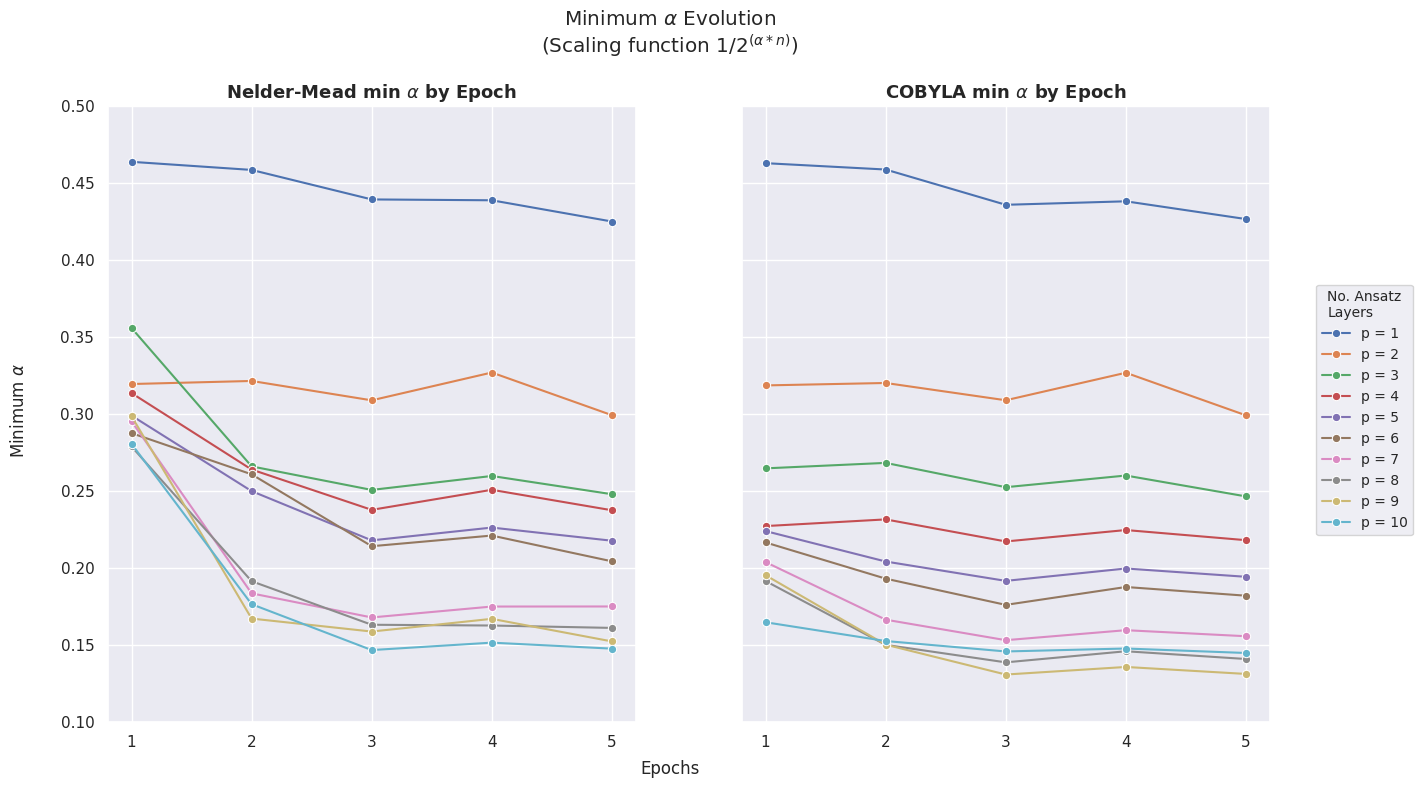

In [46]:
cobyla_stats = pd.read_csv("./results/validation_statistics/train10_val242_COBYLA.csv")
nelder_stats = pd.read_csv("./results/validation_statistics/train10_val242_NelderMead.csv")

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 8), sharey = 'row', sharex = 'col')

axes_flat = axes.flatten()

ax1 = axes[0]
ax2 = axes[1]
for p in range(1, 11):
    idx = p - 1
    x = [i + 1 for i in range(epochs)]
    n_y = [nelder_stats["min_alpha"][idx*epochs + i] for i in range(epochs)]
    sns.lineplot(x = x, y = n_y, ax = ax1, label = f"p = {p}", marker = "o" )

    c_y = [cobyla_stats["min_alpha"][idx*epochs + i] for i in range(epochs)]
    sns.lineplot(x = x, y = c_y, ax = ax2, label = f"p = {p}", marker = "o" )


    #ax1.legend(fontsize = 7, loc="upper right")
    ax1.get_legend().remove()
    ax1.set_title(f"Nelder-Mead min $\\alpha$ by Epoch", fontsize=13, fontweight="bold")

    ax1.set_xticks([0] + x)

    ax1.set_ylim(0.1, 0.6)
    ax1.set_xlim(0.8, 5.2)

    #ax2.legend(fontsize = 7, loc="upper right")
    ax2.get_legend().remove()
    ax2.set_title(f"COBYLA min $\\alpha$ by Epoch", fontsize=13, fontweight="bold")

    ax2.set_xticks([0] + x)

    ax2.set_ylim(0.1, 0.5)
    ax2.set_xlim(0.8, 5.2)


# Leyenda compartida fuera a la derecha ← añadido
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="No. Ansatz\nLayers",
    loc="center right",
    bbox_to_anchor=(1.00, 0.5),
    fontsize=10,
    title_fontsize=10,
    frameon=True
)

fig.suptitle(
    "Minimum $\\alpha$ Evolution\n(Scaling function $1/2^{(\\alpha*n)}$)",
    y=1.00
)

fig.supylabel(
    'Minimum $\\alpha$',
    fontsize=12,
    x=0.06  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Epochs',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/training_minAlpha_evolution_comparison_train10_val242.png", dpi=300, bbox_inches='tight')
plt.show()   

### **Entrenamiento 2**

In [10]:
train_set_length = 50
min_train_bitLength = 9
max_train_bitLength = 128

min_val_bitLength = 9
max_val_bitLength = 128
n_per_length = 4
val_set_length = (max_val_bitLength - min_val_bitLength + 1)*n_per_length

In [ ]:
""" #Genero los conjuntos y los guardo
train_df = generate_train_set(min_train_bitLength, max_train_bitLength, train_set_length)
train_df.to_csv(f'./training_sets/training_set_size{train_set_length}_randomBitLength_{min_train_bitLength}_to_{max_train_bitLength}.csv', index = False)

val_df = generate_val_set(min_val_bitLength, max_val_bitLength + 1, n_per_length)
val_df.to_csv(f'./validation_sets/validation_set_size{val_set_length}_bitLength_{min_val_bitLength}_to_{max_val_bitLength}.csv', index = False) """

In [11]:
#Cargo los conjuntos creados

train_df = pd.read_csv(f'./training_sets/training_set_size{train_set_length}_randomBitLength_{min_train_bitLength}_to_{max_train_bitLength}.csv')
val_df = pd.read_csv(f'./validation_sets/validation_set_size{val_set_length}_bitLength_{min_val_bitLength}_to_{max_val_bitLength}.csv')


train_set = train_df["N"].to_numpy()
val_set = val_df["N"].to_numpy()

#### Nelder-Mead

##### Ejecución paralela

In [21]:
# Tarda ~26h 
results = Parallel(n_jobs = 5)(
    
    delayed(pretraining_single_thread)(p, train_set, val_set, epochs = 5,
                                  clusterize = True, clusters = 10, delta = 0.75, l = 1, c = 4, 
                                  min_method = 'Nelder-Mead', normalizeHc = True, seed = seed,
                                  verbose = True, progress_bar = False,
                                  dir_name = f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_NelderMead_p{p}")
    for p in range(1, 11)
)

Para el numero de capas p = 1
Para el numero de capas p = 4
Para el numero de capas p = 2
Para el numero de capas p = 3
Para el numero de capas p = 5
p = 1.Epoch 01 (0720 s): min - 0.461, mean - 0.537, std - 0.087, max - 0.753
p = 1.Epoch 02 (0611 s): min - 0.458, mean - 0.496, std - 0.037, max - 0.586
p = 2.Epoch 01 (1531 s): min - 0.333, mean - 0.410, std - 0.065, max - 0.542
p = 1.Epoch 03 (0602 s): min - 0.452, mean - 0.502, std - 0.048, max - 0.603
p = 2.Epoch 02 (0717 s): min - 0.330, mean - 0.362, std - 0.024, max - 0.409
p = 3.Epoch 01 (2320 s): min - 0.307, mean - 0.444, std - 0.186, max - 0.953
p = 1.Epoch 04 (0566 s): min - 0.443, mean - 0.491, std - 0.038, max - 0.569
p = 2.Epoch 03 (0642 s): min - 0.327, mean - 0.365, std - 0.028, max - 0.419
p = 1.Epoch 05 (0597 s): min - 0.443, mean - 0.526, std - 0.067, max - 0.691
p = 1, el escalado es de 0.44251299206859596
Para el numero de capas p = 6
p = 3.Epoch 02 (1159 s): min - 0.269, mean - 0.336, std - 0.145, max - 0.770
p = 4

In [22]:
best_alphas = {}
val_stats_list = []
for p, optimal_params, best_alpha, val_stats in results:
    best_alphas[f"{p}"] = best_alpha
    val_stats_list = val_stats_list + val_stats

val_stats_df = pd.DataFrame(val_stats_list, columns = ['p', 'epoch', 'min_alpha', 'mean_alpha', 'std_alpha', 'max_alpha', 'runtime'])
val_stats_df.to_csv(f"./results/validation_statistics/train{train_set_length}_val{val_set_length}_1_NelderMead.csv", index = False)
best_alphas_df = pd.DataFrame.from_dict(best_alphas, orient = "index", columns=["best_alphas"])
best_alphas_df.index.name = "p"
best_alphas_df.to_csv(f"./results/training_best_alphas/train{train_set_length}_val{val_set_length}_1_NelderMead.csv")

##### Ejecución  secuencial

In [ ]:
val_stats_list = []
optimal_assignments = []
best_alphas = {}
for p in range(1, 11):
    print(f"Para el numero de capas p = {p}")
    
    optimal_params, best_alpha, val_stats = qaoa_pretrain_algorithm(train_set, val_set, epochs= 5, clusterize = True, clusters = 10,
                                                                     delta = 0.75, l = 1, c = 4, min_method = 'Nelder-Mead',
                                                                     p = p, normalizeHc = True,
                                                                     seed = 42, verbose = True, progress_bar = True)
    
    for epoch_idx, epoch_stats in val_stats.items():
        val_stats_list.append([p, epoch_idx] + epoch_stats)
    optimal_assignments.append(optimal_params)
    best_alphas[f"{p}"] = best_alpha
    print(f"Los parametros mas optimos proporcionan un escalado de {best_alpha}")


#### COBYLA

##### Ejecución paralela

In [14]:
results = Parallel(n_jobs = 6)(
    
    delayed(pretraining_single_thread)(p, train_set, val_set, epochs = 5,
                                  clusterize = True, clusters = 10, delta = 0.75, l = 1, c = 4, 
                                  min_method = 'COBYLA', normalizeHc = True, seed = seed,
                                  verbose = True, progress_bar = False,
                                  dir_name = f"./results/optimal_angles/train{train_set_length}_val{val_set_length}_COBYLA_p{p}")
    for p in range(1, 11)
)

Para el numero de capas p = 2
Para el numero de capas p = 1
Para el numero de capas p = 3
Para el numero de capas p = 5
Para el numero de capas p = 4
Para el numero de capas p = 6
p = 1.Epoch 01 (0603 s): min - 0.455, mean - 0.558, std - 0.156, max - 1.005
p = 2.Epoch 01 (0816 s): min - 0.336, mean - 0.433, std - 0.080, max - 0.586
p = 1.Epoch 02 (0572 s): min - 0.460, mean - 0.496, std - 0.037, max - 0.588
p = 2.Epoch 02 (0723 s): min - 0.330, mean - 0.362, std - 0.024, max - 0.409
p = 1.Epoch 03 (0590 s): min - 0.454, mean - 0.583, std - 0.258, max - 1.346
p = 3.Epoch 01 (1974 s): min - 0.267, mean - 0.383, std - 0.107, max - 0.577
p = 2.Epoch 03 (0678 s): min - 0.327, mean - 0.364, std - 0.028, max - 0.418
p = 1.Epoch 04 (0556 s): min - 0.443, mean - 0.492, std - 0.038, max - 0.567
p = 1.Epoch 05 (0628 s): min - 0.442, mean - 0.582, std - 0.231, max - 1.263
p = 1, el escalado es de 0.4415629304527306
Para el numero de capas p = 7
p = 2.Epoch 04 (0735 s): min - 0.333, mean - 0.388, s

In [17]:
best_alphas = {}
val_stats_list = []
for p, optimal_params, best_alpha, val_stats in results:
    best_alphas[f"{p}"] = best_alpha
    val_stats_list = val_stats_list + val_stats

val_stats_df = pd.DataFrame(val_stats_list, columns = ['p', 'epoch', 'min_alpha', 'mean_alpha', 'std_alpha', 'max_alpha', 'runtime'])
val_stats_df.to_csv(f"./results/validation_statistics/train{train_set_length}_val{val_set_length}_COBYLA.csv", index = False)
best_alphas_df = pd.DataFrame.from_dict(best_alphas, orient = "index", columns=["best_alphas"])
best_alphas_df.index.name = "p"
best_alphas_df.to_csv(f"./results/training_best_alphas/train{train_set_length}_val{val_set_length}_COBYLA.csv")

#### Evolución de los alphas

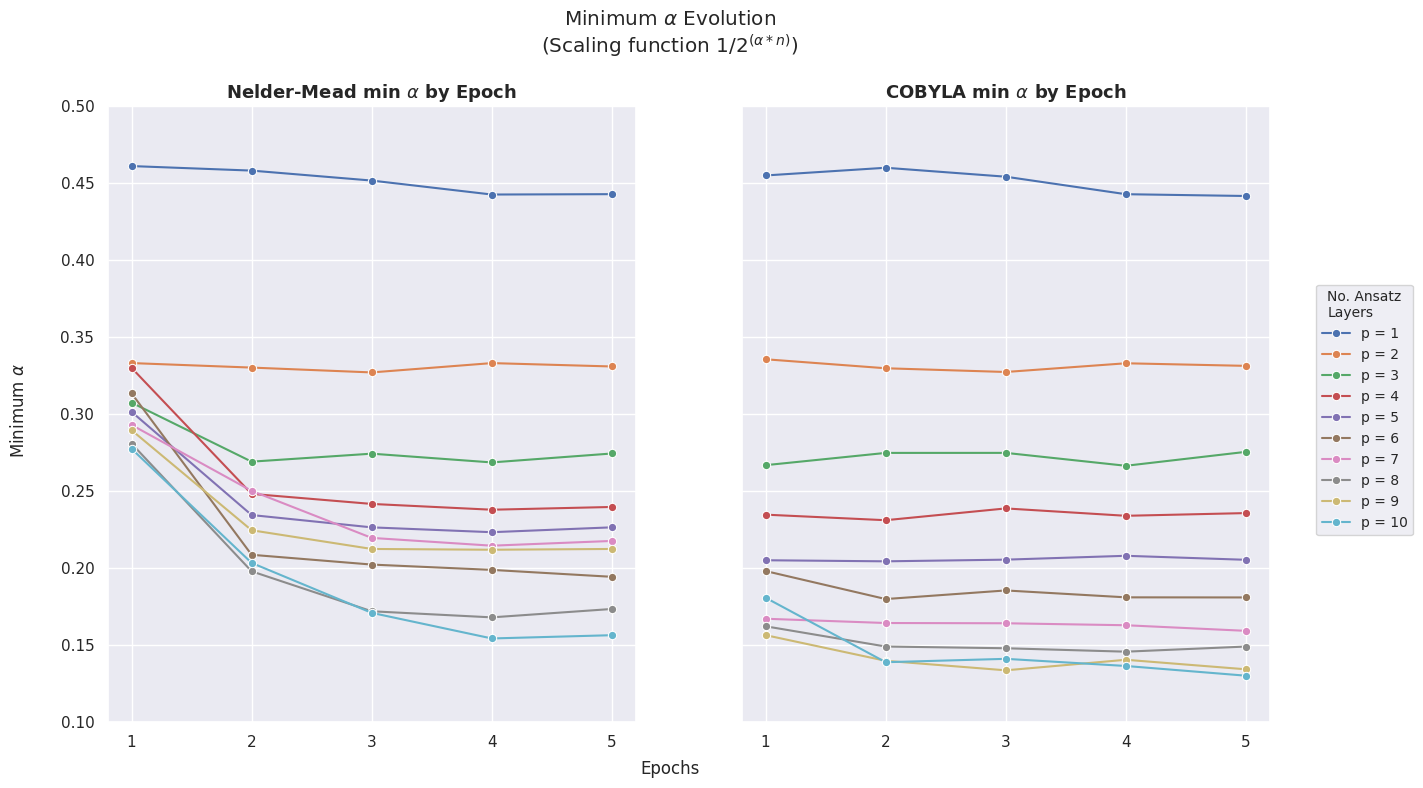

In [ ]:
cobyla_stats = pd.read_csv("./results/validation_statistics/train50_val480_COBYLA.csv")
nelder_stats = pd.read_csv("./results/validation_statistics/train50_val480_NelderMead.csv")

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 8), sharey = 'row', sharex = 'col')

axes_flat = axes.flatten()

ax1 = axes[0]
ax2 = axes[1]
for p in range(1, 11):
    idx = p - 1
    x = [i + 1 for i in range(epochs)]
    n_y = [nelder_stats["min_alpha"][idx*epochs + i] for i in range(epochs)]
    sns.lineplot(x = x, y = n_y, ax = ax1, label = f"p = {p}", marker = "o" )

    c_y = [cobyla_stats["min_alpha"][idx*epochs + i] for i in range(epochs)]
    sns.lineplot(x = x, y = c_y, ax = ax2, label = f"p = {p}", marker = "o")


    #ax1.legend(fontsize = 7, loc="upper right")
    ax1.get_legend().remove()
    ax1.set_title(f"Nelder-Mead min $\\alpha$ by Epoch", fontsize=13, fontweight="bold")

    ax1.set_xticks([0] + x)

    ax1.set_ylim(0.1, 0.6)
    ax1.set_xlim(0.8, 5.2)

    #ax2.legend(fontsize = 7, loc="upper right")
    ax2.get_legend().remove()
    ax2.set_title(f"COBYLA min $\\alpha$ by Epoch", fontsize=13, fontweight="bold")

    ax2.set_xticks([0] + x)

    ax2.set_ylim(0.1, 0.5)
    ax2.set_xlim(0.8, 5.2)


# Leyenda compartida fuera a la derecha ← añadido
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="No. Ansatz\nLayers",
    loc="center right",
    bbox_to_anchor=(1.00, 0.5),
    fontsize=10,
    title_fontsize=10,
    frameon=True
)

fig.suptitle(
    "Minimum $\\alpha$ Evolution\n(Scaling function $1/2^{(\\alpha*n)}$)",
    y=1.00
)

fig.supylabel(
    'Minimum $\\alpha$',
    fontsize=12,
    x=0.06  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Epochs',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/training_minAlpha_evolution_comparison_train50_val480.png", dpi=300, bbox_inches='tight')
plt.show()   